# Diet Distribution Analysis - $\chi^2$ Goodness of Fit Test

We have a dataset containing health and dietary information of 78 individuals. Each person is assigned to one of three dietary plans (Diet 1, Diet 2, or Diet 3). The goal is to verify if the assignment of these diets follows a uniform distribution.

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [141]:
df = pd.read_csv('weight.csv')

In [142]:
df.sample(10)

,Person,gender,Age,Height,pre.weight,Diet,weight6weeks
32,54,0,21,159,64,3,60.6
2,1,0,22,159,58,1,54.2
69,70,1,37,173,78,3,77.5
49,19,1,43,162,80,1,71.0
38,60,0,58,141,70,3,63.0
14,13,0,41,163,72,1,68.4
28,39,0,30,161,76,2,72.7
61,47,1,44,163,79,2,73.6
35,57,0,20,169,67,3,61.6
36,58,0,35,163,67,3,60.2


To determine whether the participants in the dataset are equally distributed among the three specified diets using a statistical approach.

<b> Chi-square goodness-of-fit </b>test assumptions to check:

* The data are categorical (Diet types).

* The expected frequency for each category must be at least 5.


The expected frequency for each category must be at least 5:


In [143]:
counts = df['Diet'].value_counts().sort_index()
print("Observed counts:\n", counts)

Observed counts:
 Diet
1    24
2    27
3    27
Name: count, dtype: int64


 <b> Expected values are large enough (>= 5 samples) </b> - <span style='color:green'> PASS </span>

The <b> Uniform Distribution </b>  assumes that the probability of belonging to each category is equal ($1/K$). Therefore, the expected frequency ($\text{E}$) for each diet is calculated as $N/K = 78/3 = 26$.

In [144]:
N = len(df)
k = len(counts)

expected_value = N/k

expected_value

26.0

Hypotheses:
* Null Hypothesis ($H_0$): The number of people following each diet is equal. The observed distribution perfectly fits the uniform distribution ($P_1 = P_2 = P_3$).
* Alternative Hypothesis ($H_A$): The number of people following each diet is not equal. At least one diet has a significantly different frequency than the others.

We assume a Significance Level ($\alpha$) of 0.05, which corresponds to a Confidence Level of 0.95.

In [145]:
alpha = 0.05



1. **The Core Formula**

The Chi-Square statistic is calculated by summing the squared differences between observed and expected frequencies, divided by the expected frequencies for each category.$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$
Where:
* $\chi^2$: The Chi-Square test statistic.
* $\sum$: The summation symbol (add them all up).
* $O_i$: The Observed frequency (actual data) for category $i$.
* $E_i$: The Expected frequency (theoretical data) for category $i$.
* $k$: The number of categories (e.g., 3 diets, 6 sides of a die).

2. **Degrees of Freedom ($df$)**

Because the total number of observations is fixed, if you know the counts for all categories except one, the last one is automatically determined. Therefore, the degrees of freedom are:$$df = k - 1$$

Where $k$ is the number of categories. This value is crucial because the "shape" of the Chi-Square distribution changes depending on how many categories you have.

3. **Expected Frequencies ($E_i$)**

The way you calculate $E_i$ depends on your null hypothesis ($H_0$):

* For a Uniform Distribution:

$$E_i = \frac{N}{k}$$

(Where $N$ is the total sample size and $k$ is the number of categories).

* For a Non-Uniform Distribution (specific proportions):

$$E_i = N \times p_i$$(Where $p_i$ is the hypothesized proportion for that specific category).

4. **The Decision Rule (p-value and $\alpha$)**

Once you have your $\chi^2$ value, you compare it to a Critical Value from a Chi-Square table or calculate a p-value.

Define $\alpha$ (Significance Level): Usually $0.05$.

Compare:

* If $p \text{-value} < \alpha$ $\rightarrow$ Reject $H_0$. The difference is statistically significant (it's not a fit).

* If $p \text{-value} \ge \alpha$ $\rightarrow$ Fail to reject $H_0$. The differences are likely due to chance (it's a good fit).

5. **Critical Assumptions**

For the formulas above to be valid, two main conditions must be met:

* Independence: Each observation must be independent (one person cannot be in two diet groups).

* Sample Size (The 5-rule): The Expected Frequency ($E_i$) for each category should be at least 5. If it is lower, the Chi-Square approximation becomes inaccurate (in that case, you might use an Exact Binomial or Multinomial test).

**Applied the formula:**

$$\chi^2 = \frac{(24-26)^2}{26} + \frac{(27-26)^2}{26} + \frac{(27-26)^2}{26} = \frac{4}{26} + \frac{1}{26} + \frac{1}{26} = \frac{6}{26} \approx 0.2308$$

In [146]:
chi2_stat, p_val = stats.chisquare(counts, expected_value)

In [147]:
print(f"\nTest Results:")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4f}")


Test Results:
Chi-Square Statistic: 0.2308
P-value: 0.8910


In [148]:
if p_val < alpha:
    print("Result: Significant difference (Reject H0). The diets are NOT equally represented.")
else:
    print("Result: No significant difference (Fail to reject H0). The diets are equally represented.")

Result: No significant difference (Fail to reject H0). The diets are equally represented.


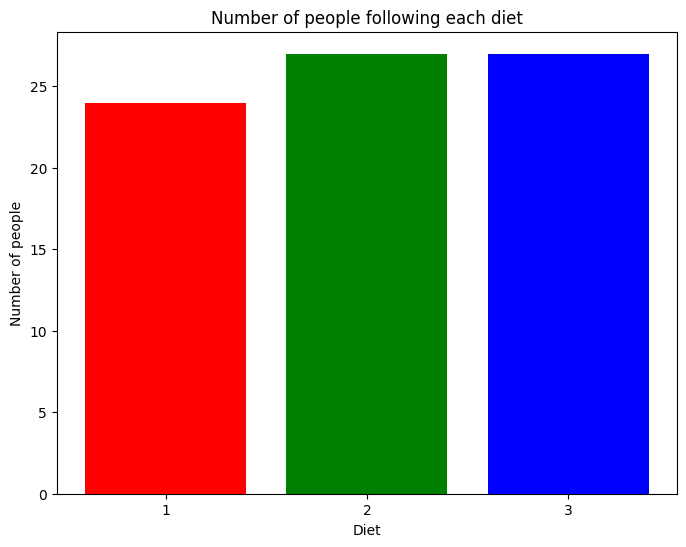

In [149]:
plt.figure(figsize=(8, 6))

bars = plt.bar(counts.index.astype(str), counts, color=['red','green','blue'])

plt.title("Number of people following each diet")
plt.xlabel("Diet")
plt.ylabel('Number of people')

plt.show()
